# **🍃 Renewable Energy Consumption and Generation Analytics for College Campuses**


---



## **📶 Statistical Analysis**:


---



**Business Objectives**

*   Improve Renewable Energy Generation

*   Optimize Energy Consumption

*   Improve Battery Performance

*   Understand Weather Impact

*   Improve Maintenance



---



# **Energy Consumption Dataset**
---



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
energy_consumption_df = pd.read_excel("/content/Fact_Energy_Consumption_2021_Cleaned.xlsx")

In [ ]:
energy_consumption_df.head()

,consumption_record_id,campus_id,date,load_category_id,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr,is_weekend,data_quality_flag
0,1,1,2021-01-01,1,987.10,104.54,91.51,6899.10,0,VALID
1,2,1,2021-01-01,2,678.03,73.11,85.00,4738.95,0,VALID
2,3,1,2021-01-01,3,373.53,39.47,76.33,2610.71,0,VALID
3,4,1,2021-01-01,4,473.76,50.23,79.54,3311.22,0,VALID
4,5,1,2021-01-01,5,286.26,30.41,83.49,2000.74,0,VALID


**❓Business Question 1**

**What is the typical energy consumption in 2021?**

**📘 Descriptive Statistics**

In [ ]:
mean_energy = energy_consumption_df['energy_consumed_kwh'].mean()
median_energy = energy_consumption_df['energy_consumed_kwh'].median()
mode_energy = energy_consumption_df['energy_consumed_kwh'].mode()[0]

print(f"Mean   : {mean_energy:.2f}")
print(f"Median : {median_energy:.2f}")
print(f"Mode   : {mode_energy:.2f}")

Mean   : 697.11
Median : 428.21
Mode   : 85.53


**❓Business Question 2**

**How is the typical energy consumption in 2021?**

**📘 Measure of Dispersion**

In [ ]:
std_energy = energy_consumption_df['energy_consumed_kwh'].std()
variance_energy = energy_consumption_df['energy_consumed_kwh'].var()

print(f"Standard Deviation : {std_energy:.2f}")
print(f"Variance : {variance_energy:.2f}")

Standard Deviation : 775.68
Variance : 601676.44


In [ ]:
q1_energy = energy_consumption_df['energy_consumed_kwh'].quantile(0.25)
q2_energy = energy_consumption_df['energy_consumed_kwh'].quantile(0.50)
q3_energy = energy_consumption_df['energy_consumed_kwh'].quantile(0.75)

iqr_energy = q3_energy - q1_energy

print(f"Q1 : {q1_energy:.2f}")
print(f"Q2 : {q2_energy:.2f}")
print(f"Q3 : {q3_energy:.2f}")
print(f"IQR : {iqr_energy:.2f}")

Q1 : 199.77
Q2 : 428.21
Q3 : 878.07
IQR : 678.30


**❓Business Question 3**

**Is energy consumption normally distributed?**

**📘 Distribution Analysis**

In [ ]:
skewness_energy = energy_consumption_df['energy_consumed_kwh'].skew()
kurtosis_energy = energy_consumption_df['energy_consumed_kwh'].kurt()

print(f"Skewness : {skewness_energy:.2f}")
print(f"Kurtosis : {kurtosis_energy:.2f}")

Skewness : 2.38
Kurtosis : 7.00


Skewness > 0 depicts that the distribution is right skewed.

**ie. Most observations are concentrated at lower generation values.**

Kurtosis > 0 depicts that the distribution has long tails.

**ie. There are more extreme values present in the distribution.**



---

**❓Business Question 4**

**Does occupancy or peak demand or energy cost influence energy consumption?**

**📘 Correlation Analysis**

In [ ]:
correlation_matrix = energy_consumption_df[
    [
        'energy_consumed_kwh',
        'peak_demand_kw',
        'occupancy_pct',
        'energy_cost_inr'
    ]
].corr()

correlation_matrix

,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr
energy_consumed_kwh,1.000000,0.993988,0.336621,0.992704
peak_demand_kw,0.993988,1.000000,0.328195,0.998213
occupancy_pct,0.336621,0.328195,1.000000,0.325455
energy_cost_inr,0.992704,0.998213,0.325455,1.000000


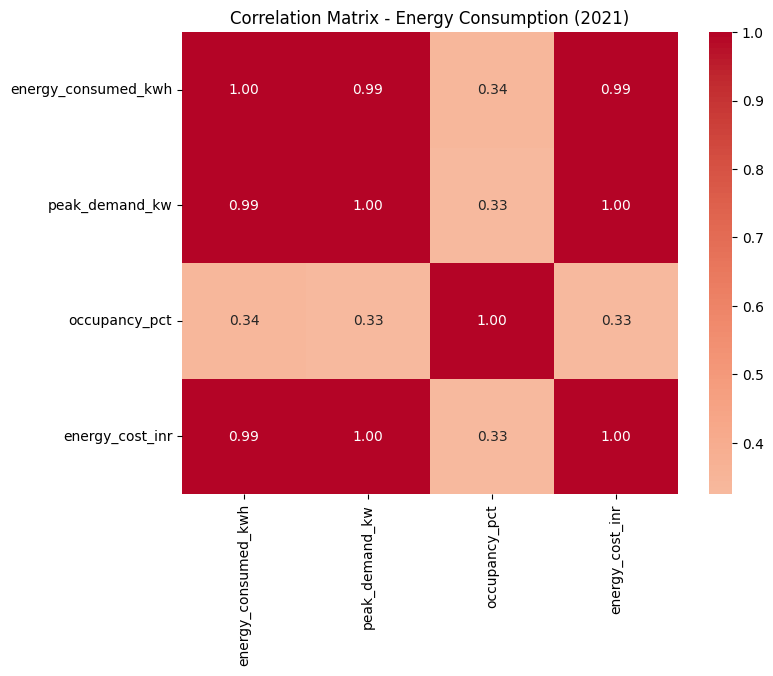

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    center = 0,
    cmap="coolwarm",   # Reverse of coolwarm
    fmt=".2f"
)
plt.title("Correlation Matrix - Energy Consumption (2021)")
plt.show()

**Business Insight**

*   As peak demand increases, energy consumption also increases.
*   Higher energy consumption is associated with higher energy costs.

*   There is essentially moderate relationship between occupancy and energy consumption.



---


**❓Business Question 5**

**Does energy consumption differ between weekdays and weekends?**

**📘 Independent t-test**



---

**Null Hypothesis (H₀)**

There is no significant difference in average energy consumption between weekdays and weekends.

**Alternative Hypothesis (H₁)**

There is a significant difference in average energy consumption between weekdays and weekends.

In [ ]:
weekday_energy = energy_consumption_df[
    energy_consumption_df['is_weekend'] == 0
]['energy_consumed_kwh']

weekend_energy = energy_consumption_df[
    energy_consumption_df['is_weekend'] == 1
]['energy_consumed_kwh']

In [ ]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    weekday_energy,
    weekend_energy,
    equal_var=False
)

print(f"T-statistic : {t_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

T-statistic : 122.3447
P-value     : 0.0000


Reject the null hypothesis.

In [ ]:
print(f"Weekday Mean : {weekday_energy.mean():.2f} kWh")
print(f"Weekend Mean : {weekend_energy.mean():.2f} kWh")

Weekday Mean : 783.75 kWh
Weekend Mean : 479.71 kWh


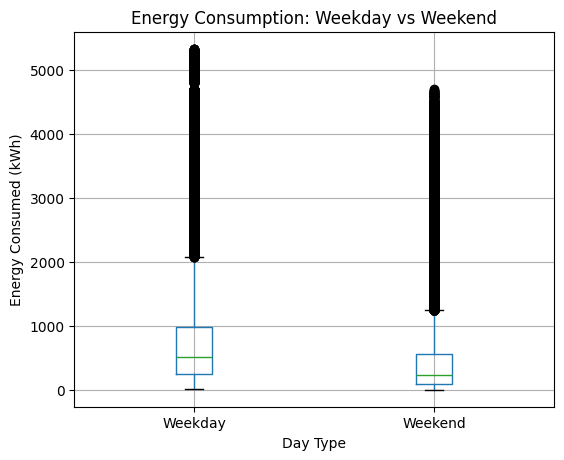

In [ ]:
import matplotlib.pyplot as plt

energy_consumption_df.boxplot(
    column='energy_consumed_kwh',
    by='is_weekend',
    figsize=(6,5)
)

plt.xticks([1,2], ['Weekday', 'Weekend'])
plt.title('Energy Consumption: Weekday vs Weekend')
plt.suptitle('')
plt.xlabel('Day Type')
plt.ylabel('Energy Consumed (kWh)')
plt.grid(True)

plt.show()

Both groups have many high-value outliers, which is normal for energy data because some campuses/load categories consume much more energy than others.

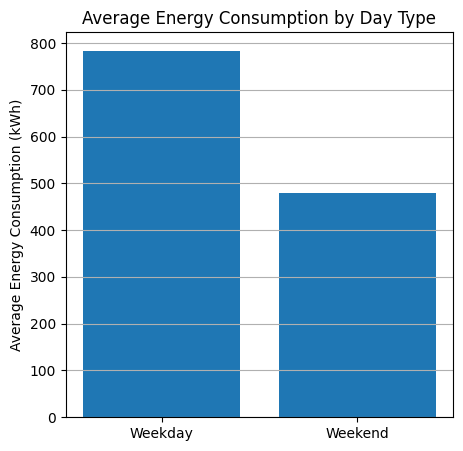

In [ ]:
means = energy_consumption_df.groupby('is_weekend')['energy_consumed_kwh'].mean()

plt.figure(figsize=(5,5))
plt.bar(['Weekday','Weekend'], means)

plt.ylabel('Average Energy Consumption (kWh)')
plt.title('Average Energy Consumption by Day Type')
plt.grid(axis='y')

plt.show()

The Independent Samples t-test showed a significant difference in energy consumption between weekdays and weekends


**❓Business Question 6**

**Does energy consumption differ across load categories?**

**📘 ANOVA Analysis**

**t-test → compares 2 groups**
Example: Weekday vs Weekend

**ANOVA → compares 3 or more groups**
Example: 7 Load Categories

**Hypotheses**

**H₀:** Mean energy consumption is the same across all load categories.

**H₁:** At least one load category has a different mean energy consumption.

In [ ]:
from scipy.stats import f_oneway

groups = []

for category in sorted(energy_consumption_df['load_category_id'].unique()):
    groups.append(
        energy_consumption_df[
            energy_consumption_df['load_category_id'] == category
        ]['energy_consumed_kwh']
    )

In [ ]:
f_statistic, p_value = f_oneway(*groups)

print(f"F-statistic : {f_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

F-statistic : 26921.9058
P-value     : 0.0000


**Since p-value < 0.05, Reject H₀.**

In [ ]:
category_mean = energy_consumption_df.groupby(
    'load_category_id'
)['energy_consumed_kwh'].mean()

print(category_mean)

load_category_id
1    1558.120925
2    1056.397154
3     498.853660
4     652.572093
5     372.053011
6     274.410751
7     467.396776
Name: energy_consumed_kwh, dtype: float64


In [ ]:
summary = energy_consumption_df.groupby(
    'load_category_id'
)['energy_consumed_kwh'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
)

print(summary)

                  Count         Mean    Median          Std     Min      Max
load_category_id                                                            
1                 54750  1558.120925  1084.965  1190.229246  124.69  5334.78
2                 54750  1056.397154   734.475   816.769668   59.42  4057.74
3                 54750   498.853660   322.865   495.007097   11.03  2600.70
4                 54750   652.572093   443.910   570.242064   22.32  3038.21
5                 54750   372.053011   237.970   350.906969    6.98  1730.57
6                 54750   274.410751   183.095   241.644742    9.06  1308.05
7                 54750   467.396776   326.185   357.019285   37.89  1600.46


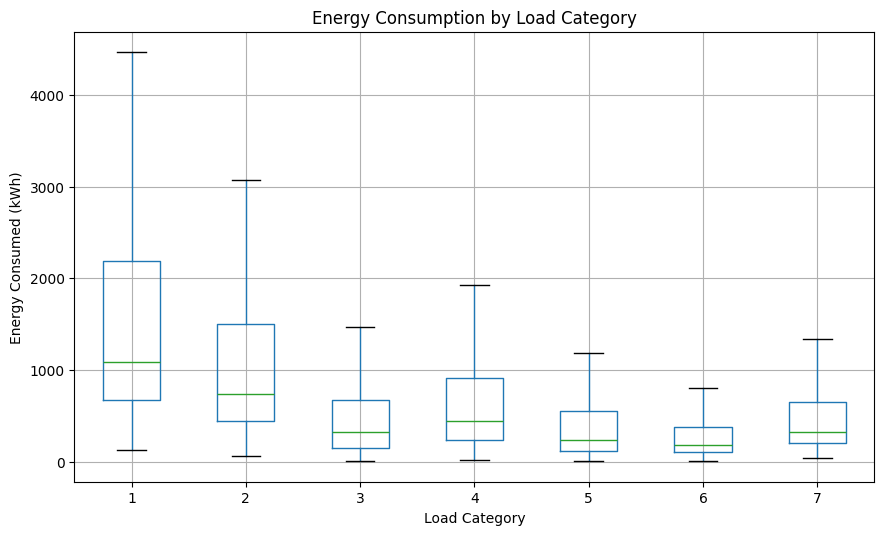

In [ ]:
energy_consumption_df.boxplot(
    column='energy_consumed_kwh',
    by='load_category_id',
    figsize=(10,6),
    showfliers=False
)

plt.title('Energy Consumption by Load Category')
plt.suptitle('')
plt.xlabel('Load Category')
plt.ylabel('Energy Consumed (kWh)')
plt.grid(True)

plt.show()

**❓Business Question 7**

**How has energy consumption changed over time?**

**📘 Time Series Analysis**

In [ ]:
energy_consumption_df['date'] = pd.to_datetime(
    energy_consumption_df['date']
)

In [ ]:
energy_consumption_df['month'] = energy_consumption_df['date'].dt.month

In [ ]:
monthly_energy = energy_consumption_df.groupby(
    'month'
)['energy_consumed_kwh'].sum().reset_index()

print(monthly_energy)

    month  energy_consumed_kwh
0       1          22606509.82
1       2          20947307.56
2       3          23463400.23
3       4          22631011.31
4       5          20247365.86
5       6          19901393.18
6       7          23037833.88
7       8          22995081.13
8       9          22521896.79
9      10          22732830.33
10     11          22610492.25
11     12          23474166.86


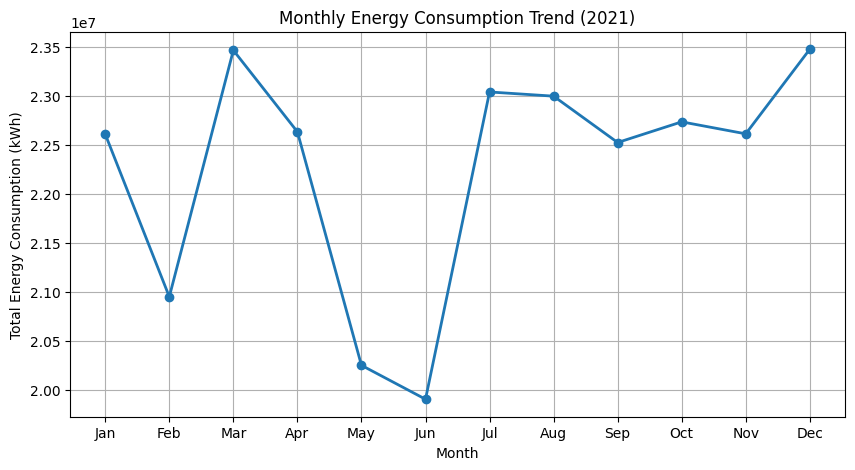

In [ ]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,5))

plt.plot(
    month_names,
    monthly_energy['energy_consumed_kwh'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Energy Consumption Trend (2021)')
plt.xlabel('Month')
plt.ylabel('Total Energy Consumption (kWh)')
plt.grid(True)

plt.show()

Overall, the time series analysis indicates a varying energy demand across the year rather than a consistent increasing or decreasing trend.


# **Weather Dataset**


---



**❓ Business Question 1**

**What are the typical weather conditions observed in 2021?**

**📘 Descriptive Statistics**

In [ ]:
import pandas as pd

In [ ]:
weather_df = pd.read_excel("/content/Fact_Weather_2021_Cleaned.xlsx")

In [ ]:
weather_df.describe().round(2)

,weather_record_id,campus_id,date,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm
count,54750.00,54750.0,54750,54750.00,54750.00,54750.00,54750.00,54750.00
mean,27375.50,75.5,2021-07-02 00:00:00.000000256,21.52,75.43,729.45,4.09,5.89
min,1.00,1.0,2021-01-01 00:00:00,8.80,52.40,147.00,0.40,0.00
25%,13688.25,38.0,2021-04-02 00:00:00,20.30,65.00,685.02,2.80,1.20
50%,27375.50,75.5,2021-07-02 00:00:00,21.50,71.30,770.20,4.00,2.20
75%,41062.75,113.0,2021-10-01 00:00:00,22.80,84.60,797.90,5.40,9.20
max,54750.00,150.0,2021-12-31 00:00:00,31.40,98.00,884.50,9.40,53.30
std,15805.11,43.3,NaN,2.49,12.19,102.38,1.62,7.50


In [ ]:
weather_df[
    [
        'temperature_c',
        'humidity_pct',
        'solar_irradiance_wm2',
        'wind_speed_ms',
        'rainfall_mm'
    ]
].agg(['mean','median','std','min','max']).round(2)

,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm
mean,21.52,75.43,729.45,4.09,5.89
median,21.50,71.30,770.20,4.00,2.20
std,2.49,12.19,102.38,1.62,7.50
min,8.80,52.40,147.00,0.40,0.00
max,31.40,98.00,884.50,9.40,53.30


In [ ]:
weather_condition = weather_df['weather_condition'].value_counts()

print(weather_condition)

weather_condition
PARTLY CLOUDY    39932
SUNNY            11030
RAINY             3788
Name: count, dtype: int64


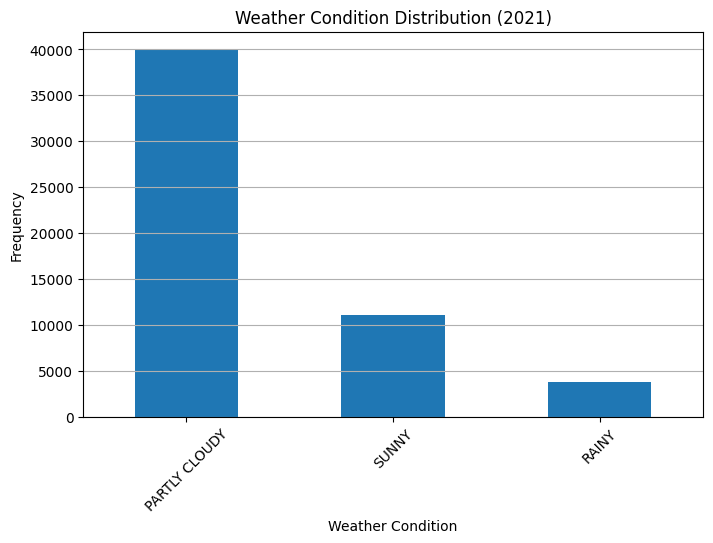

In [ ]:
import matplotlib.pyplot as plt

weather_condition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Weather Condition Distribution (2021)')
plt.xlabel('Weather Condition')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

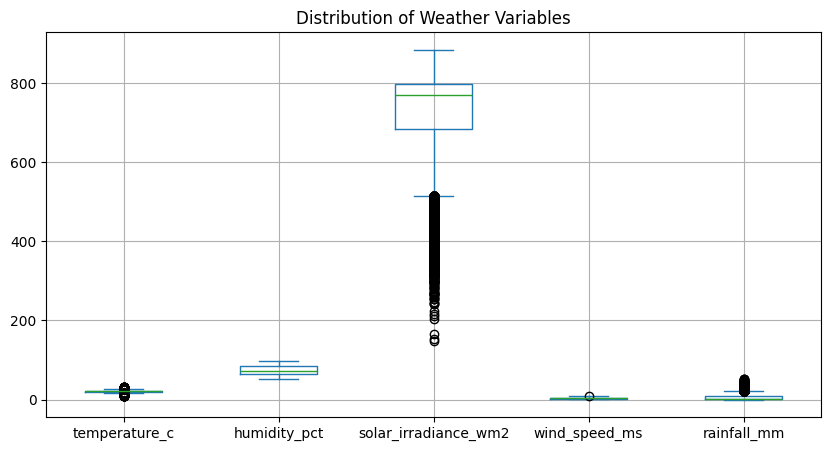

In [ ]:
weather_df[
    [
        'temperature_c',
        'humidity_pct',
        'solar_irradiance_wm2',
        'wind_speed_ms',
        'rainfall_mm'
    ]
].plot(
    kind='box',
    figsize=(10,5)
)

plt.title('Distribution of Weather Variables')
plt.grid(True)

plt.show()

The weather in 2021 was predominantly Partly Cloudy, with moderate temperatures , high humidity, and strong solar irradiance. These conditions indicate generally favorable weather for renewable energy generation throughout the year.

**❓ Business Question 2**

**Is there a relationship between weather variables (temperature, humidity, solar irradiance, wind speed, and rainfall)?**

**📘 Correlation Analysis**

In [ ]:
weather_corr = weather_df[
    [
        'temperature_c',
        'humidity_pct',
        'solar_irradiance_wm2',
        'wind_speed_ms',
        'rainfall_mm'
    ]
].corr()

print(weather_corr.round(3))

                      temperature_c  humidity_pct  solar_irradiance_wm2  \
temperature_c                 1.000        -0.224                 0.105   
humidity_pct                 -0.224         1.000                -0.836   
solar_irradiance_wm2          0.105        -0.836                 1.000   
wind_speed_ms                -0.086         0.646                -0.584   
rainfall_mm                  -0.072         0.772                -0.971   

                      wind_speed_ms  rainfall_mm  
temperature_c                -0.086       -0.072  
humidity_pct                  0.646        0.772  
solar_irradiance_wm2         -0.584       -0.971  
wind_speed_ms                 1.000        0.552  
rainfall_mm                   0.552        1.000  


<Axes: >

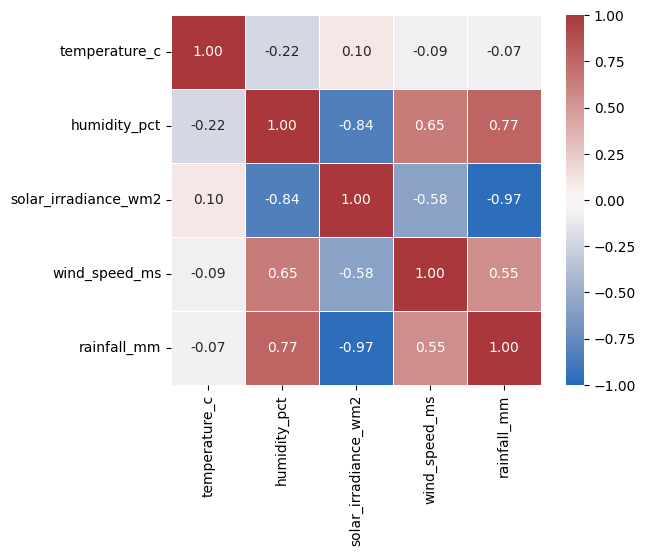

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    weather_corr,
    annot=True,
    cmap='vlag',
    center=0,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

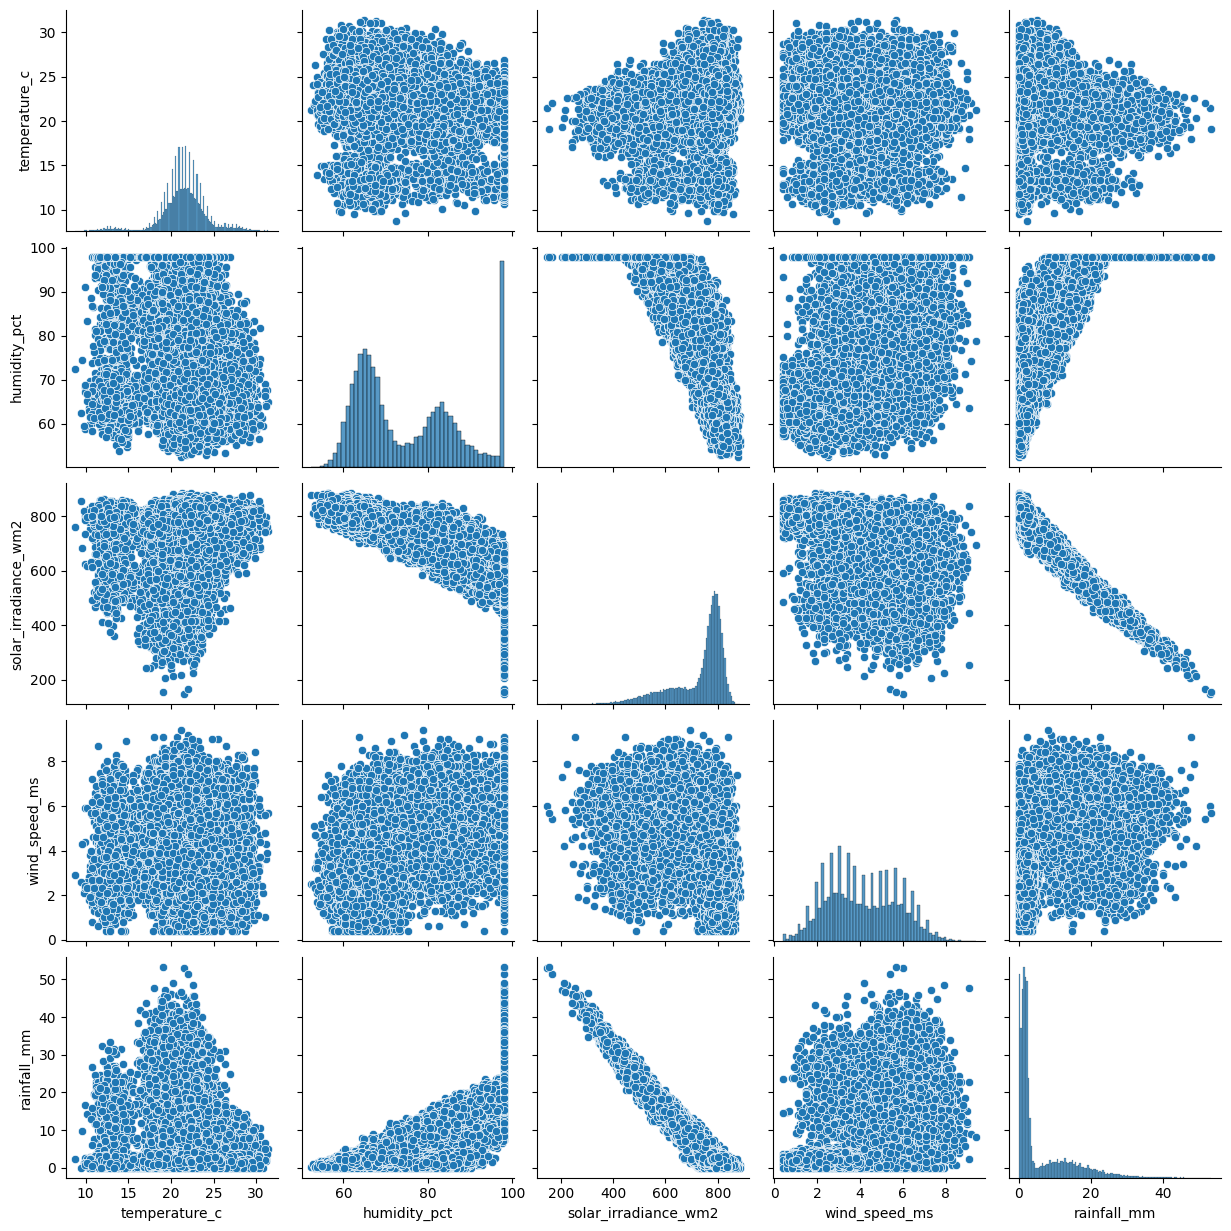

In [ ]:
sns.pairplot(
    weather_df[
        [
            'temperature_c',
            'humidity_pct',
            'solar_irradiance_wm2',
            'wind_speed_ms',
            'rainfall_mm'
        ]
    ]
)

plt.show()

**Key Findings**

*   Solar irradiance and rainfall have a
very strong negative correlation (r = -0.97), indicating that **higher rainfall is associated with lower solar irradiance.**

*   Humidity and solar irradiance have a strong negative correlation (r = -0.84), suggesting that **increased humidity reduces available sunlight.**

*   Humidity and rainfall have a strong positive correlation (r = 0.77), meaning **rainfall generally occurs under high humidity conditions.**

*   Temperature has weak correlations with the other weather variables.


Temperature has only weak relationships with the other weather variables, indicating that sunlight availability is more affected by atmospheric conditions than by temperature.


---



**❓ Business Question 3**

**Does solar irradiance differ under different weather conditions?**

**📘 ANOVA Analysis**

**Hypotheses**

**H₀:** The mean solar irradiance is the same across all weather conditions.

**H₁:** At least one weather condition has a different mean solar irradiance.

In [ ]:
weather_mean = weather_df.groupby(
    'weather_condition'
)['solar_irradiance_wm2'].mean()

print(weather_mean)

weather_condition
PARTLY CLOUDY    729.255417
RAINY            471.597043
SUNNY            818.693300
Name: solar_irradiance_wm2, dtype: float64


In [ ]:
from scipy.stats import f_oneway

groups = []

for condition in weather_df['weather_condition'].unique():
    groups.append(
        weather_df[
            weather_df['weather_condition'] == condition
        ]['solar_irradiance_wm2']
    )

f_statistic, p_value = f_oneway(*groups)

print(f"F-statistic : {f_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

F-statistic : 39720.4660
P-value     : 0.0000


**Since p-value < 0.05, Reject H₀.**

In [ ]:
summary = weather_df.groupby(
    'weather_condition'
)['solar_irradiance_wm2'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
)

print(summary.round(2))

                   Count    Mean  Median    Std    Min    Max
weather_condition                                            
PARTLY CLOUDY      39932  729.26   760.5  74.05  485.8  875.1
RAINY               3788  471.60   483.8  58.58  147.0  599.9
SUNNY              11030  818.69   815.9  14.04  800.0  884.5


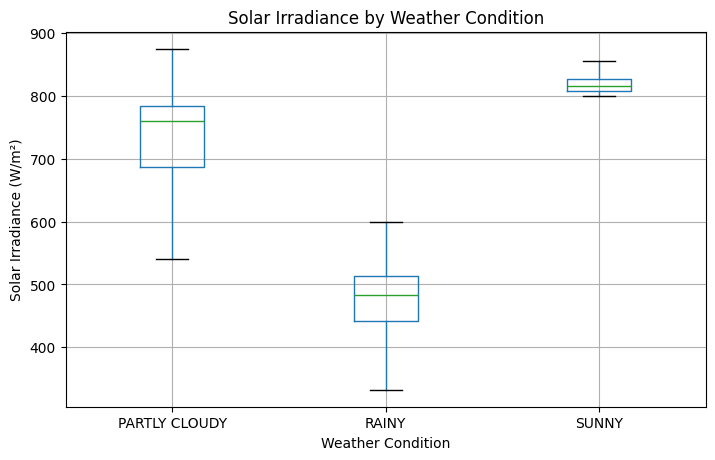

In [ ]:
import matplotlib.pyplot as plt

weather_df.boxplot(
    column='solar_irradiance_wm2',
    by='weather_condition',
    figsize=(8,5),
    showfliers=False
)

plt.title('Solar Irradiance by Weather Condition')
plt.suptitle('')
plt.xlabel('Weather Condition')
plt.ylabel('Solar Irradiance (W/m²)')
plt.grid(True)

plt.show()

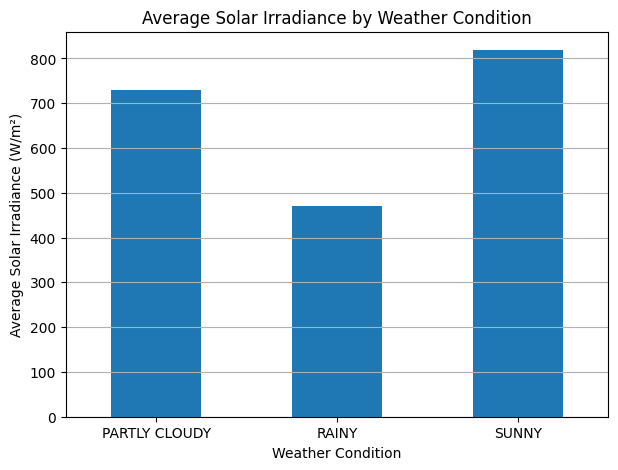

In [ ]:
weather_mean.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Average Solar Irradiance by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Solar Irradiance (W/m²)')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

Sunny conditions produced the highest solar irradiance, while Rainy conditions produced the lowest, confirming that weather conditions have a significant impact on available solar energy.

**❓ Business Question 4**

**Can weather conditions predict rainfall?**

**📘 Independent t-test**

**Hypotheses**

**H₀:** Weather conditions do not significantly predict rainfall.

**H₁:** Weather conditions significantly predict rainfall.

In [ ]:
X = pd.get_dummies(
    weather_df['weather_condition'],
    drop_first=True,
    dtype=int
)

y = weather_df['rainfall_mm']

In [ ]:
rainfall_mean = weather_df.groupby(
    'weather_condition'
)['rainfall_mm'].mean()

print(rainfall_mean)

weather_condition
PARTLY CLOUDY     5.406351
RAINY            25.678907
SUNNY             0.845204
Name: rainfall_mm, dtype: float64


In [ ]:
from scipy.stats import f_oneway

groups = []

for category in sorted(weather_df['weather_condition'].unique()):
    groups.append(
        weather_df[
            weather_df['weather_condition'] == category
        ]['rainfall_mm']
    )

f_statistic, p_value = f_oneway(*groups)

print(f"F-statistic : {f_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

F-statistic : 37105.9158
P-value     : 0.0000


**Since Prob(F-statistic) < 0.05, Reject H₀.**

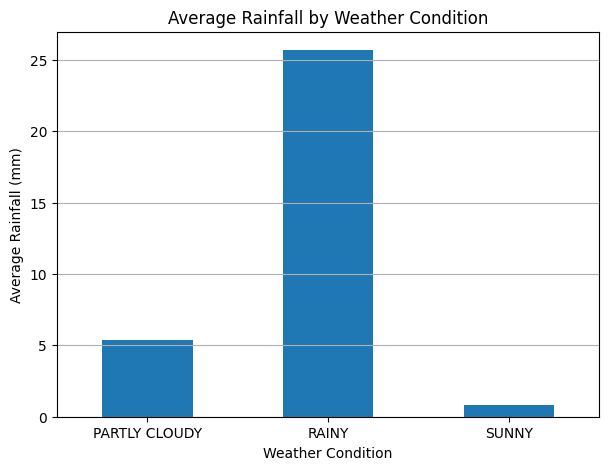

In [ ]:
import matplotlib.pyplot as plt

rainfall_mean.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Average Rainfall by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

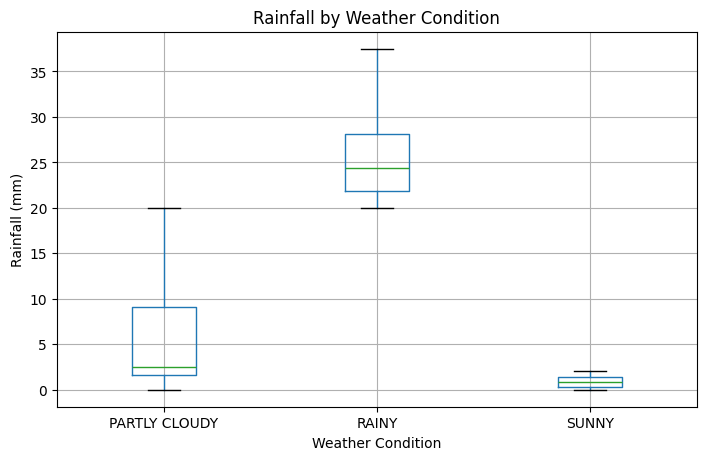

In [ ]:
weather_df.boxplot(
    column='rainfall_mm',
    by='weather_condition',
    figsize=(8,5),
    showfliers=False
)

plt.title('Rainfall by Weather Condition')
plt.suptitle('')
plt.xlabel('Weather Condition')
plt.ylabel('Rainfall (mm)')
plt.grid(True)

plt.show()

**❓ Business Question 5**

**Can temperature, humidity, wind speed, and rainfall predict solar irradiance?**

**📘 Regression Analysis**

**Hypotheses**

**H₀:** Temperature, humidity, wind speed, and rainfall do not significantly predict solar irradiance.

**H₁:** At least one of the weather variables significantly predicts solar irradiance.

In [ ]:
import statsmodels.api as sm

X = weather_df[
    [
        'temperature_c',
        'humidity_pct',
        'wind_speed_ms',
        'rainfall_mm'
    ]
]

y = weather_df['solar_irradiance_wm2']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     solar_irradiance_wm2   R-squared:                       0.962
Model:                              OLS   Adj. R-squared:                  0.962
Method:                   Least Squares   F-statistic:                 3.452e+05
Date:                  Sat, 25 Jul 2026   Prob (F-statistic):               0.00
Time:                          14:32:49   Log-Likelihood:            -2.4168e+05
No. Observations:                 54750   AIC:                         4.834e+05
Df Residuals:                     54745   BIC:                         4.834e+05
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           930.9658  

In [ ]:
coefficients = pd.DataFrame({
    'Coefficient': model.params,
    'P-value': model.pvalues
})

print(coefficients)

               Coefficient   P-value
const           930.965770  0.000000
temperature_c    -0.053323  0.136004
humidity_pct     -1.793624  0.000000
wind_speed_ms    -0.074265  0.285239
rainfall_mm     -10.995941  0.000000


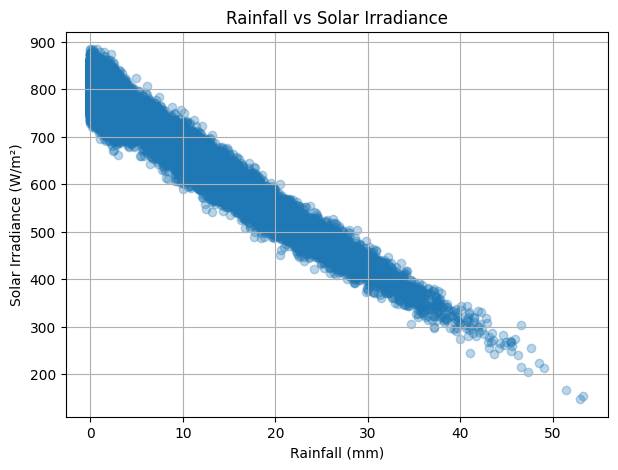

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    weather_df['rainfall_mm'],
    weather_df['solar_irradiance_wm2'],
    alpha=0.3
)

plt.xlabel('Rainfall (mm)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.title('Rainfall vs Solar Irradiance')

plt.grid(True)

plt.show()

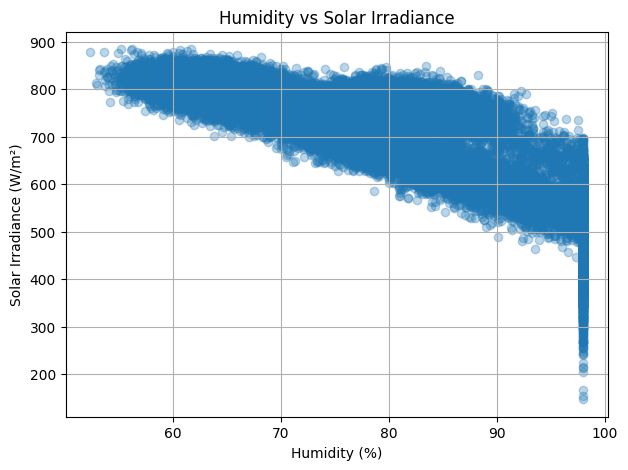

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    weather_df['humidity_pct'],
    weather_df['solar_irradiance_wm2'],
    alpha=0.3
)

plt.xlabel('Humidity (%)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.title('Humidity vs Solar Irradiance')

plt.grid(True)

plt.show()

**As humidity increases, solar irradiance decreases.**

**❓ Business Question 6**

**How has solar irradiance changed over time?**

**📘 Time Series Analysis**



In [ ]:
weather_df['date'] = pd.to_datetime(weather_df['date'])

monthly_solar = (
    weather_df.groupby(weather_df['date'].dt.month)['solar_irradiance_wm2']
    .mean()
    .reset_index()
)

monthly_solar.columns = ['month', 'solar_irradiance_wm2']

print(monthly_solar.round(2))

    month  solar_irradiance_wm2
0       1                787.83
1       2                788.12
2       3                787.55
3       4                788.50
4       5                788.33
5       6                622.85
6       7                622.12
7       8                624.22
8       9                622.08
9      10                773.60
10     11                775.15
11     12                775.16


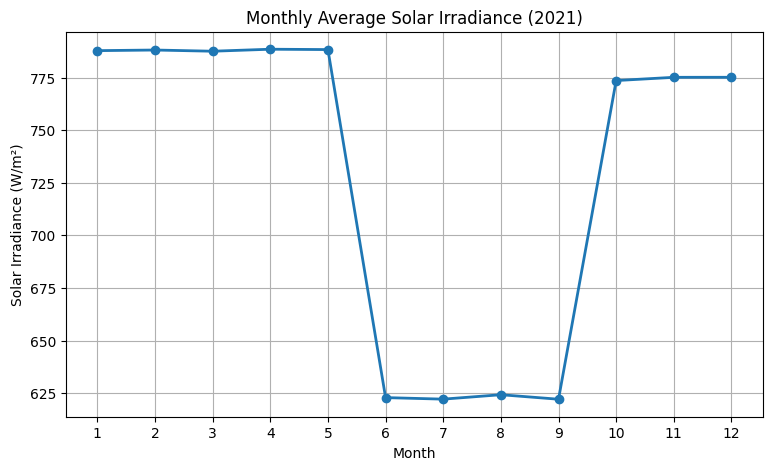

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(
    monthly_solar['month'],
    monthly_solar['solar_irradiance_wm2'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Average Solar Irradiance (2021)')
plt.xlabel('Month')
plt.ylabel('Solar Irradiance (W/m²)')
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

This seasonal pattern indicates that solar irradiance varies throughout the year, with the lowest levels occurring during the mid-year period and the highest levels during the beginning and end of the year.

# **Renewable Generation Dataset (2021)**

---



**❓ Business Question 1**

**What is the typical renewable energy generation in 2021?**

**📘 Descriptive Statistics**

In [ ]:
import pandas as pd

In [ ]:
energy_generation_2021_df = pd.read_excel("/content/Fact_Renewable_Generation_2021_Cleaned.xlsx")

In [ ]:
energy_generation_2021_df.head()

,generation_record_id,campus_id,date,solar_generation_kwh,wind_generation_kwh,total_generation_kwh,renewable_capacity_kw,capacity_utilization_pct,weather_dependency_score,maintenance_impact_flag,data_quality_flag
0,1,1,2021-01-01,1679.16,96.66,1775.82,537,13.84,74.82,NO,VALID
1,2,1,2021-01-02,1603.71,0.00,1603.71,537,12.42,68.55,NO,VALID
2,3,1,2021-01-03,1568.39,9.67,1578.06,537,12.22,68.31,NO,VALID
3,4,1,2021-01-04,1601.31,0.00,1601.31,537,12.38,63.97,NO,VALID
4,5,1,2021-01-05,1954.51,193.32,2147.83,537,16.70,77.55,NO,VALID


In [ ]:
mean_generation = energy_generation_2021_df['total_generation_kwh'].mean()
median_generation = energy_generation_2021_df['total_generation_kwh'].median()
mode_generation = energy_generation_2021_df['total_generation_kwh'].mode()

In [ ]:
print(f"Mean Renewable Generation : {mean_generation:.2f} kWh")
print(f"Median Renewable Generation : {median_generation:.2f} kWh")
print("Mode Renewable Generation : ",mode_generation)

Mean Renewable Generation : 2857.94 kWh
Median Renewable Generation : 2836.74 kWh
Mode Renewable Generation :  0     1686.99
1     1946.60
2     2034.94
3     2109.37
4     2121.49
5     2220.17
6     2689.36
7     3126.08
8     3413.72
9     3771.88
10    3917.22
11    3976.05
Name: total_generation_kwh, dtype: float64


**Mean > Median**

**It might be Right Skewed**



---



**❓Business Question 2**

**How consistent is renewable generation?**

**📘 Measure of Distribution**

In [ ]:
std_generation = energy_generation_2021_df['total_generation_kwh'].std()

print(f"Standard Deviation : {std_generation:.2f} kWh")

Standard Deviation : 917.76 kWh


In [ ]:
varience_generation = energy_generation_2021_df['total_generation_kwh'].var()

print(f"Varience : {varience_generation:.2f}")

Varience : 842282.09


In [ ]:
q1_generation = energy_generation_2021_df['total_generation_kwh'].quantile(0.25)
q2_generation = energy_generation_2021_df['total_generation_kwh'].quantile(0.50)
q3_generation = energy_generation_2021_df['total_generation_kwh'].quantile(0.75)

iqr_generation = q3_generation - q1_generation

print(f"Q1 : {q1_generation:.2f}")
print(f"Q2 : {q2_generation:.2f}")
print(f"Q3 : {q3_generation:.2f}")
print(f"IQR : {iqr_generation:.2f}")

Q1 : 2134.30
Q2 : 2836.74
Q3 : 3549.54
IQR : 1415.24




---


**What is the shape of the renewable generation distribution?**

**📘Distribution Analysis**

In [ ]:
skewness_generation = energy_generation_2021_df['total_generation_kwh'].skew()
kurtosis_generation = energy_generation_2021_df['total_generation_kwh'].kurt()

print(f"Skewness : {skewness_generation:.2f}")
print(f"Kurtosis : {kurtosis_generation:.2f}")

Skewness : 0.10
Kurtosis : -0.57




---
**❓Business Question 3:**

**Which factors influence renewable energy generation?**

**📘Correlation Analysis**

In [ ]:
correlation_matrix = energy_generation_2021_df[
    [
        'total_generation_kwh',
        'renewable_capacity_kw',
        'capacity_utilization_pct',
        'weather_dependency_score'
    ]
].corr()

correlation_matrix

,total_generation_kwh,renewable_capacity_kw,capacity_utilization_pct,weather_dependency_score
total_generation_kwh,1.000000,0.804839,0.589043,0.509936
renewable_capacity_kw,0.804839,1.000000,0.017170,0.010277
capacity_utilization_pct,0.589043,0.017170,1.000000,0.875828
weather_dependency_score,0.509936,0.010277,0.875828,1.000000


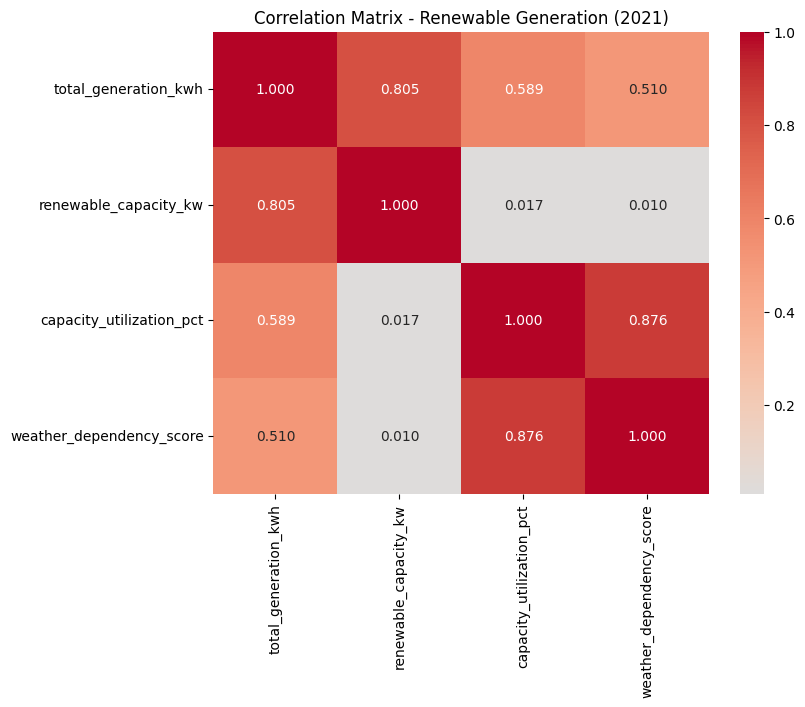

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".3f"
)

plt.title("Correlation Matrix - Renewable Generation (2021)")
plt.show()

**❓ Business Question 4**

**Does renewable energy generation differ under different weather conditions?**

**📘 ANOVA Analysis**

**Hypotheses**

**H₀:** Mean renewable energy generation is the same across all weather conditions.

**H₁:** At least one weather condition has a different mean renewable energy generation.

In [ ]:
energy_generation_2021_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   generation_record_id      54750 non-null  int64         
 1   campus_id                 54750 non-null  int64         
 2   date                      54750 non-null  datetime64[ns]
 3   solar_generation_kwh      54750 non-null  float64       
 4   wind_generation_kwh       54750 non-null  float64       
 5   total_generation_kwh      54750 non-null  float64       
 6   renewable_capacity_kw     54750 non-null  int64         
 7   capacity_utilization_pct  54750 non-null  float64       
 8   weather_dependency_score  54750 non-null  float64       
 9   maintenance_impact_flag   54750 non-null  object        
 10  data_quality_flag         54750 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(3), object(2)
memory usage: 4.6+ MB


In [ ]:
energy_generation_2021_df['date'] = pd.to_datetime(
    energy_generation_2021_df['date']
)

weather_df['date'] = pd.to_datetime(
    weather_df['date']
)

In [ ]:
renew_weather_df = energy_generation_2021_df.merge(
    weather_df[['campus_id', 'date', 'weather_condition']],
    on=['campus_id', 'date'],
    how='left'
)

In [ ]:
print(renew_weather_df.shape)

print(renew_weather_df['weather_condition'].isna().sum())

(54750, 12)
0


In [ ]:
weather_mean = renew_weather_df.groupby(
    'weather_condition'
)['total_generation_kwh'].mean()

print(weather_mean)

weather_condition
PARTLY CLOUDY    2827.649058
RAINY            1363.081357
SUNNY            3480.998554
Name: total_generation_kwh, dtype: float64


In [ ]:
from scipy.stats import f_oneway

groups = []

for condition in renew_weather_df['weather_condition'].unique():
    groups.append(
        renew_weather_df[
            renew_weather_df['weather_condition'] == condition
        ]['total_generation_kwh']
    )

f_statistic, p_value = f_oneway(*groups)

print(f"F-statistic : {f_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

F-statistic : 10498.3714
P-value     : 0.0000


**Since p-value < 0.05, Reject H₀.**

In [ ]:
summary = renew_weather_df.groupby(
    'weather_condition'
)['total_generation_kwh'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
)

print(summary.round(2))

                   Count     Mean   Median     Std      Min      Max
weather_condition                                                   
PARTLY CLOUDY      39932  2827.65  2813.47  767.55  1076.57  5604.43
RAINY               3788  1363.08  1330.19  423.05   345.20  2718.22
SUNNY              11030  3481.00  3510.38  909.77  1477.31  5988.30


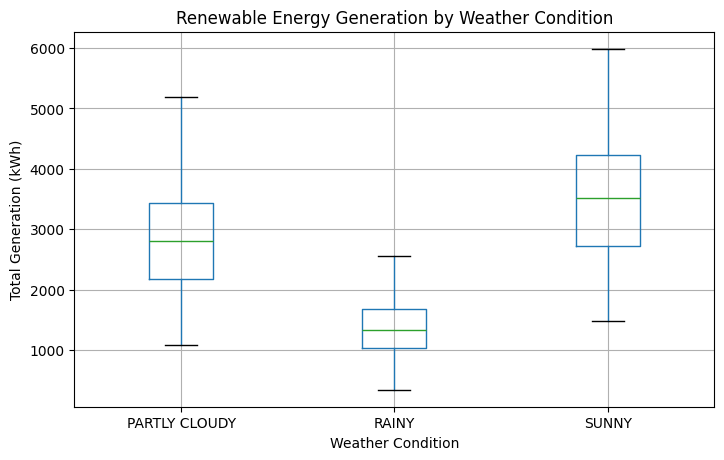

In [ ]:
import matplotlib.pyplot as plt

renew_weather_df.boxplot(
    column='total_generation_kwh',
    by='weather_condition',
    figsize=(8,5),
    showfliers=False
)

plt.title('Renewable Energy Generation by Weather Condition')
plt.suptitle('')
plt.xlabel('Weather Condition')
plt.ylabel('Total Generation (kWh)')
plt.grid(True)

plt.show()

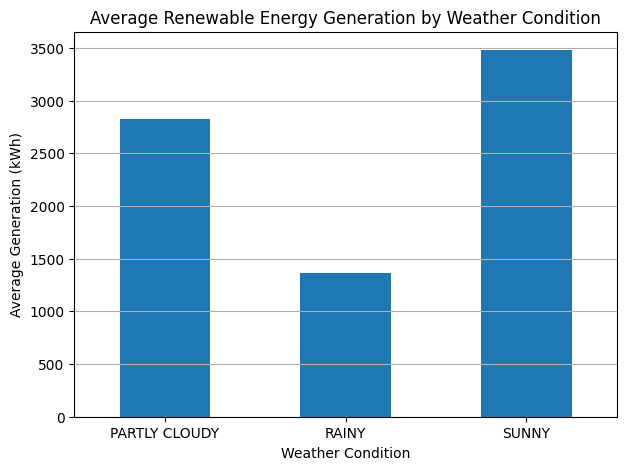

In [ ]:
weather_mean.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Average Renewable Energy Generation by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Generation (kWh)')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

**Key Findings**


*   Sunny weather recorded the highest average renewable energy generation.

*   Partly Cloudy weather showed moderate renewable energy generation.

*   Rainy weather had the lowest average renewable energy generation.

**❓ Business Question 5**

**Does maintenance impact renewable energy generation??**

**📘 Independent t-test**

**Hypotheses**

**H₀:** Mean renewable energy generation is the same for assets with and without maintenance impact.

**H₁:** Mean renewable energy generation differs between assets with and without maintenance impact.

In [ ]:
print(energy_generation_2021_df['maintenance_impact_flag'].value_counts())

maintenance_impact_flag
NO     52584
YES     2166
Name: count, dtype: int64


In [ ]:
maintenance = energy_generation_2021_df[
    energy_generation_2021_df['maintenance_impact_flag'] == 'Yes'
]['total_generation_kwh']

no_maintenance = energy_generation_2021_df[
    energy_generation_2021_df['maintenance_impact_flag'] == 'No'
]['total_generation_kwh']

In [ ]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    maintenance,
    no_maintenance,
    equal_var=False
)

print(f"T-statistic : {t_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

T-statistic : nan
P-value     : nan


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


**Since p-value < 0.05, you Reject H₀.**

In [ ]:
print(f"Maintenance Impact    : {maintenance.mean():.2f} kWh")
print(f"No Maintenance Impact : {no_maintenance.mean():.2f} kWh")

Maintenance Impact    : nan kWh
No Maintenance Impact : nan kWh


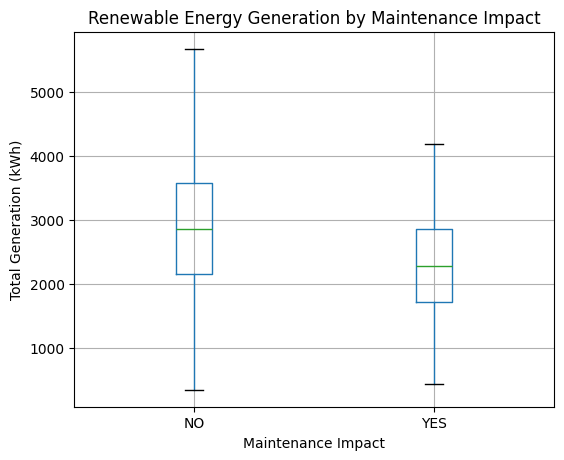

In [ ]:
import matplotlib.pyplot as plt

energy_generation_2021_df.boxplot(
    column='total_generation_kwh',
    by='maintenance_impact_flag',
    figsize=(6,5),
    showfliers=False
)

plt.title('Renewable Energy Generation by Maintenance Impact')
plt.suptitle('')
plt.xlabel('Maintenance Impact')
plt.ylabel('Total Generation (kWh)')
plt.grid(True)

plt.show()

**❓ Business Question 6**

**Which renewable energy source contributes the most to total renewable generation?**

**📘 Comparative Analysis (Mean Comparison)**

In [ ]:
source_mean = energy_generation_2021_df[
    ['solar_generation_kwh', 'wind_generation_kwh']
].mean()

print(source_mean)

solar_generation_kwh    2516.995814
wind_generation_kwh      340.948450
dtype: float64


In [ ]:
summary = energy_generation_2021_df[
    ['solar_generation_kwh', 'wind_generation_kwh']
].agg(['mean', 'median', 'std', 'min', 'max']).T

print(summary.round(2))

                         mean   median     std     min      max
solar_generation_kwh  2517.00  2490.94  916.62  156.51  4978.96
wind_generation_kwh    340.95   295.12  270.39    0.00  1602.61


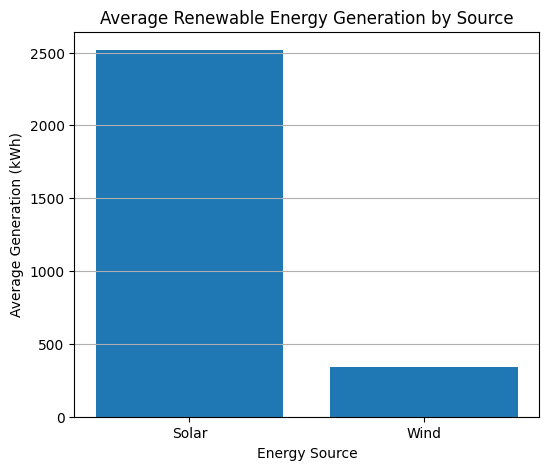

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    ['Solar', 'Wind'],
    source_mean
)

plt.title('Average Renewable Energy Generation by Source')
plt.xlabel('Energy Source')
plt.ylabel('Average Generation (kWh)')
plt.grid(axis='y')

plt.show()

In [ ]:
total_generation = (
    energy_generation_2021_df['solar_generation_kwh'].sum() +
    energy_generation_2021_df['wind_generation_kwh'].sum()
)

contribution = (
    energy_generation_2021_df[
        ['solar_generation_kwh', 'wind_generation_kwh']
    ].sum() / total_generation
) * 100

print(contribution.round(2))

solar_generation_kwh    88.07
wind_generation_kwh     11.93
dtype: float64


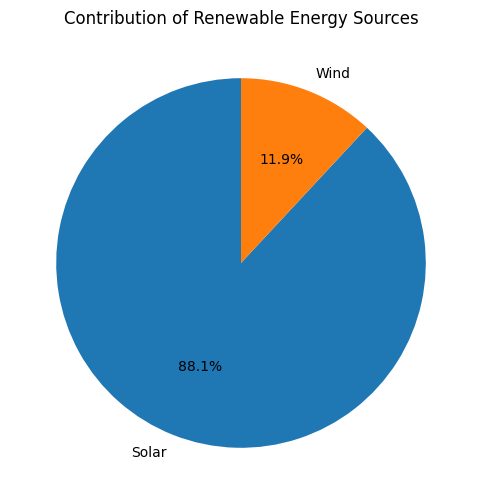

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    contribution,
    labels=['Solar', 'Wind'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Contribution of Renewable Energy Sources')

plt.show()

**Solar energy is the dominant renewable energy source.**

**❓ Business Question 8**

**How has renewable energy generation changed over time?**

**📘 Time Series Analysis**

In [ ]:
energy_generation_2021_df['date'] = pd.to_datetime(
    energy_generation_2021_df['date']
)

monthly_generation = (
    energy_generation_2021_df.groupby(
        energy_generation_2021_df['date'].dt.month
    )['total_generation_kwh']
    .sum()
    .reset_index()
)

monthly_generation.columns = ['month', 'total_generation_kwh']

print(monthly_generation.round(2))

    month  total_generation_kwh
0       1           14132195.30
1       2           12769520.76
2       3           14114793.31
3       4           13690366.10
4       5           14117865.03
5       6           11487260.91
6       7           11862408.30
7       8           11932556.73
8       9           11465369.79
9      10           13729912.18
10     11           13341633.39
11     12           13828566.63


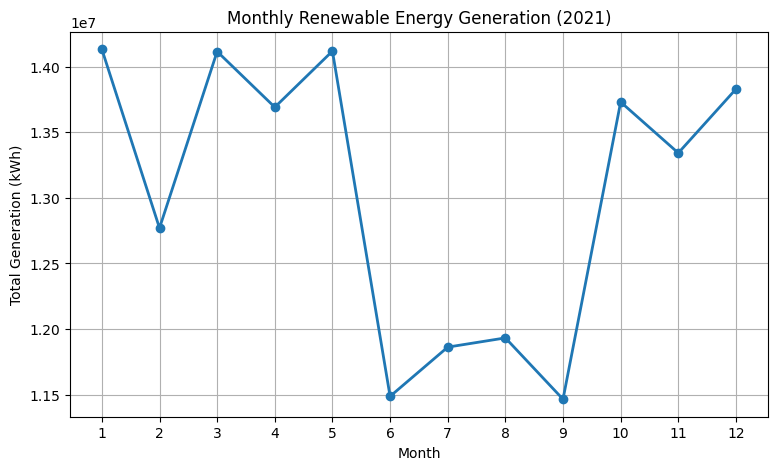

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(
    monthly_generation['month'],
    monthly_generation['total_generation_kwh'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Renewable Energy Generation (2021)')
plt.xlabel('Month')
plt.ylabel('Total Generation (kWh)')
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

In [ ]:
monthly_generation['growth_pct'] = (
    monthly_generation['total_generation_kwh']
    .pct_change() * 100
)

print(monthly_generation.round(2))

    month  total_generation_kwh  growth_pct
0       1           14132195.30         NaN
1       2           12769520.76       -9.64
2       3           14114793.31       10.54
3       4           13690366.10       -3.01
4       5           14117865.03        3.12
5       6           11487260.91      -18.63
6       7           11862408.30        3.27
7       8           11932556.73        0.59
8       9           11465369.79       -3.92
9      10           13729912.18       19.75
10     11           13341633.39       -2.83
11     12           13828566.63        3.65


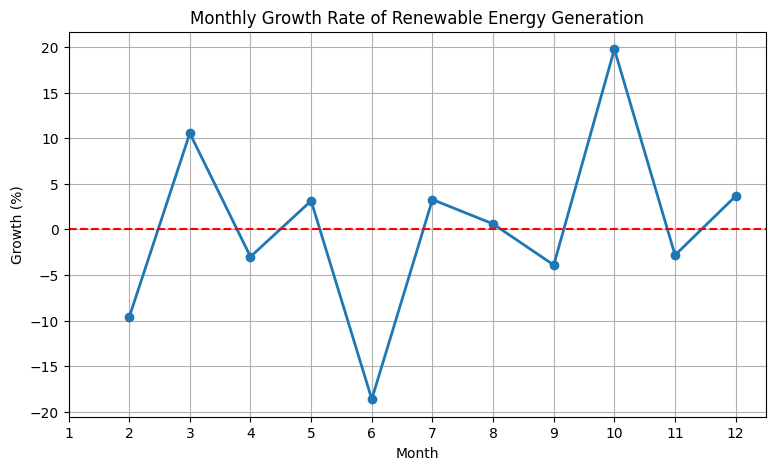

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    monthly_generation['month'],
    monthly_generation['growth_pct'],
    marker='o',
    linewidth=2
)

plt.axhline(0, color='red', linestyle='--')

plt.title('Monthly Growth Rate of Renewable Energy Generation')
plt.xlabel('Month')
plt.ylabel('Growth (%)')
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

Renewable energy generation remained high from January to May, declined significantly from June to September, and increased again during October to December.


# **Battery Storage Dataset**


---




In [ ]:
battery_storage_df = pd.read_excel("/content/Fact_Battery_Operations_2021_Cleaned.xlsx")

In [ ]:
battery_storage_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   battery_record_id       54750 non-null  int64         
 1   campus_id               54750 non-null  int64         
 2   date                    54750 non-null  datetime64[ns]
 3   charge_kwh              54750 non-null  float64       
 4   discharge_kwh           54750 non-null  float64       
 5   state_of_charge_pct     54750 non-null  float64       
 6   battery_efficiency_pct  54750 non-null  float64       
 7   battery_cycles          54750 non-null  float64       
 8   battery_health_pct      54750 non-null  float64       
 9   data_quality_flag       54750 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 4.2+ MB


**❓ Business Question 1**

**What is the typical battery storage performance in 2021?**

**📘 Descriptive Statistics**

In [ ]:
battery_summary = battery_storage_df[
    [
        'charge_kwh',
        'discharge_kwh',
        'state_of_charge_pct',
        'battery_efficiency_pct',
        'battery_cycles',
        'battery_health_pct'
    ]
].describe().T

print(battery_summary.round(2))

                          count    mean    std    min     25%     50%     75%  \
charge_kwh              54750.0  187.24  90.20  32.34  116.47  177.91  251.00   
discharge_kwh           54750.0  110.93  53.84  32.42   68.70   96.26  146.04   
state_of_charge_pct     54750.0   69.51  32.91  15.00   36.04   84.06  100.00   
battery_efficiency_pct  54750.0   95.91   0.05  95.82   95.86   95.91   95.96   
battery_cycles          54750.0    0.12   0.03   0.07    0.10    0.12    0.14   
battery_health_pct      54750.0   99.78   0.14  99.55   99.65   99.77   99.90   

                           max  
charge_kwh              485.79  
discharge_kwh           289.79  
state_of_charge_pct     100.00  
battery_efficiency_pct   96.00  
battery_cycles            0.21  
battery_health_pct      100.00  


In [ ]:
summary = battery_storage_df[
    [
        'charge_kwh',
        'discharge_kwh',
        'state_of_charge_pct',
        'battery_efficiency_pct',
        'battery_cycles',
        'battery_health_pct'
    ]
].agg(
    ['mean', 'median', 'std', 'min', 'max']
).T

print(summary.round(2))

                          mean  median    std    min     max
charge_kwh              187.24  177.91  90.20  32.34  485.79
discharge_kwh           110.93   96.26  53.84  32.42  289.79
state_of_charge_pct      69.51   84.06  32.91  15.00  100.00
battery_efficiency_pct   95.91   95.91   0.05  95.82   96.00
battery_cycles            0.12    0.12   0.03   0.07    0.21
battery_health_pct       99.78   99.77   0.14  99.55  100.00


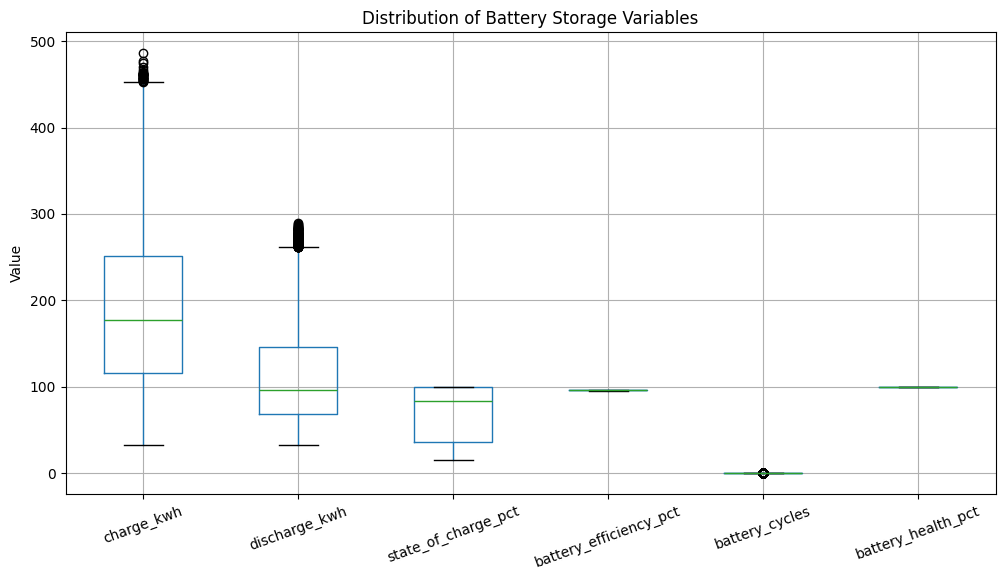

In [ ]:
import matplotlib.pyplot as plt

battery_storage_df[
    [
        'charge_kwh',
        'discharge_kwh',
        'state_of_charge_pct',
        'battery_efficiency_pct',
        'battery_cycles',
        'battery_health_pct'
    ]
].boxplot(figsize=(12,6))

plt.title('Distribution of Battery Storage Variables')
plt.ylabel('Value')
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

**❓ Business Question 2**

**Is there a relationship between battery charge level, discharge level, and battery efficiency?**

**📘 Correlation Analysis**

In [ ]:
correlation = battery_storage_df[
    [
        'charge_kwh',
        'discharge_kwh',
        'battery_efficiency_pct'
    ]
].corr()

print(correlation.round(3))

                        charge_kwh  discharge_kwh  battery_efficiency_pct
charge_kwh                   1.000          -0.56                   0.068
discharge_kwh               -0.560           1.00                  -0.040
battery_efficiency_pct       0.068          -0.04                   1.000


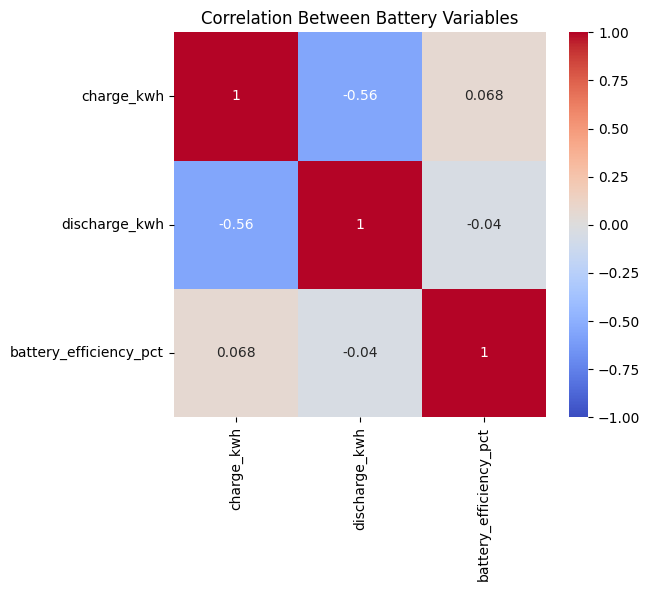

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Battery Variables')

plt.show()

**Batteries with higher charge levels generally have lower discharge levels at the same point in time.**

**Battery efficiency remains relatively stable regardless of changes in charge or discharge levels.**

**❓ Business Question 3**

**Does battery efficiency differ under different battery health conditions?**

**📘 ANOVA Analysis**

**Hypotheses**

**H₀:** Mean battery efficiency is the same across all battery health conditions.

**H₁:** At least one battery health condition has a different mean battery efficiency.

In [ ]:
battery_storage_df['battery_health_category'] = pd.cut(
    battery_storage_df['battery_health_pct'],
    bins=[99.5, 99.7, 99.85, 100],
    labels=['Low', 'Medium', 'High']
)

In [ ]:
health_mean = battery_storage_df.groupby(
    'battery_health_category'
)['battery_efficiency_pct'].mean()

print(health_mean)

battery_health_category
Low       95.852553
Medium    95.912070
High      95.972646
Name: battery_efficiency_pct, dtype: float64


/tmp/ipykernel_1585/4281328670.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  health_mean = battery_storage_df.groupby(


In [ ]:
from scipy.stats import f_oneway

low = battery_storage_df[
    battery_storage_df['battery_health_category'] == 'Low'
]['battery_efficiency_pct']

medium = battery_storage_df[
    battery_storage_df['battery_health_category'] == 'Medium'
]['battery_efficiency_pct']

high = battery_storage_df[
    battery_storage_df['battery_health_category'] == 'High'
]['battery_efficiency_pct']

f_statistic, p_value = f_oneway(low, medium, high)

print(f"F-statistic : {f_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

F-statistic : 244471.7886
P-value     : 0.0000


In [ ]:
summary = battery_storage_df.groupby(
    'battery_health_category'
)['battery_efficiency_pct'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
)

print(summary.round(3))

                         Count    Mean  Median    Std    Min    Max
battery_health_category                                            
Low                      20562  95.853   95.85  0.017  95.82  95.88
Medium                   14766  95.912   95.91  0.018  95.88  95.94
High                     19422  95.973   95.97  0.017  95.94  96.00


/tmp/ipykernel_1585/737942037.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = battery_storage_df.groupby(


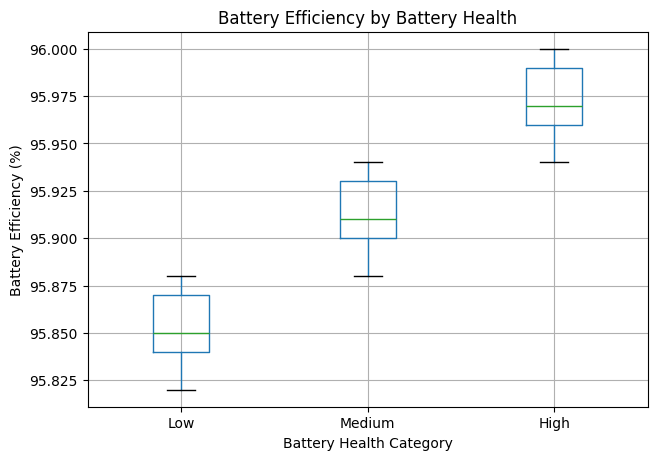

In [ ]:
battery_storage_df.boxplot(
    column='battery_efficiency_pct',
    by='battery_health_category',
    figsize=(7,5),
    showfliers=False
)

plt.title('Battery Efficiency by Battery Health')
plt.suptitle('')
plt.xlabel('Battery Health Category')
plt.ylabel('Battery Efficiency (%)')
plt.grid(True)

plt.show()

Since p-value < 0.05, there is a significant difference in battery efficiency across battery health conditions.


---



**❓ Business Question 4**

**How has battery efficiency changed over time?**

**📘 Time Series Analysis**

In [ ]:
monthly_efficiency = (
    battery_storage_df.groupby(
        battery_storage_df['date'].dt.month
    )['battery_efficiency_pct']
    .mean()
    .reset_index()
)

monthly_efficiency.columns = ['month', 'battery_efficiency_pct']

print(monthly_efficiency.round(3))

    month  battery_efficiency_pct
0       1                  95.994
1       2                  95.982
2       3                  95.968
3       4                  95.955
4       5                  95.939
5       6                  95.920
6       7                  95.901
7       8                  95.883
8       9                  95.868
9      10                  95.856
10     11                  95.843
11     12                  95.830


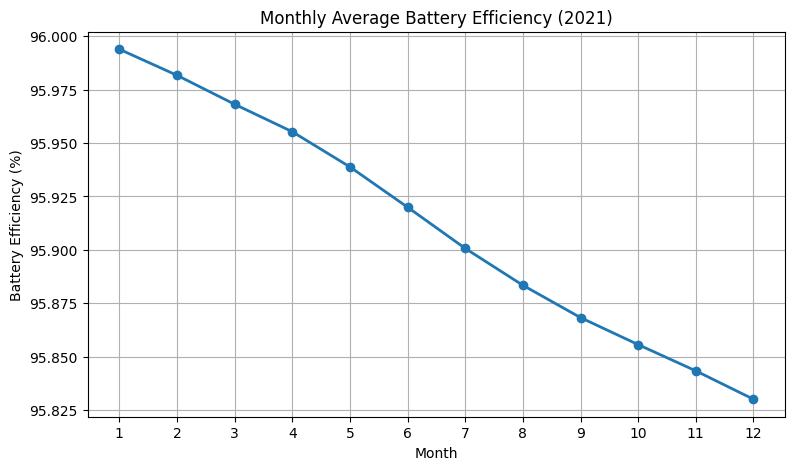

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(
    monthly_efficiency['month'],
    monthly_efficiency['battery_efficiency_pct'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Average Battery Efficiency (2021)')
plt.xlabel('Month')
plt.ylabel('Battery Efficiency (%)')
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

**The time series analysis indicates that battery efficiency decreased slightly over the course of 2021.**

**The battery storage system maintained stable and high performance throughout the year.**


# **Grid Transactions Dataset**


---



In [ ]:
grid_df = pd.read_excel("/content/Fact_Grid_Transactions_2021_Cleaned.xlsx")

In [ ]:
grid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   grid_transaction_id  54750 non-null  int64         
 1   campus_id            54750 non-null  int64         
 2   date                 54750 non-null  datetime64[ns]
 3   import_kwh           54750 non-null  float64       
 4   export_kwh           54750 non-null  int64         
 5   import_cost_inr      54750 non-null  float64       
 6   export_revenue_inr   54750 non-null  int64         
 7   net_grid_energy_kwh  54750 non-null  float64       
 8   grid_dependency_pct  54750 non-null  float64       
 9   data_quality_flag    54750 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(4), object(1)
memory usage: 4.2+ MB


**❓ Business Question 1**

**What are the typical grid import, export, and cost patterns in 2021?**

**📘 Descriptive Statistics**

In [ ]:
grid_summary = grid_df[
    [
        'import_kwh',
        'export_kwh',
        'import_cost_inr',
        'export_revenue_inr',
        'net_grid_energy_kwh',
        'grid_dependency_pct'
    ]
].describe().T

print(grid_summary.round(2))

                       count      mean      std      min       25%       50%  \
import_kwh           54750.0   2204.66   411.74  1129.30   1915.61   2189.15   
export_kwh           54750.0      0.00     0.00     0.00      0.00      0.00   
import_cost_inr      54750.0  15854.23  2969.04  8101.92  13724.12  15716.95   
export_revenue_inr   54750.0      0.00     0.00     0.00      0.00      0.00   
net_grid_energy_kwh  54750.0   2204.66   411.74  1129.30   1915.61   2189.15   
grid_dependency_pct  54750.0     39.30     7.24    22.75     32.15     43.45   

                          75%       max  
import_kwh            2521.87   3351.34  
export_kwh               0.00      0.00  
import_cost_inr      18077.48  25408.52  
export_revenue_inr       0.00      0.00  
net_grid_energy_kwh   2521.87   3351.34  
grid_dependency_pct     45.20     48.40  


In [ ]:
summary = grid_df[
    [
        'import_kwh',
        'export_kwh',
        'import_cost_inr',
        'export_revenue_inr',
        'net_grid_energy_kwh',
        'grid_dependency_pct'
    ]
].agg(
    ['mean', 'median', 'std', 'min', 'max']
).T

print(summary.round(2))

                         mean    median      std      min       max
import_kwh            2204.66   2189.15   411.74  1129.30   3351.34
export_kwh               0.00      0.00     0.00     0.00      0.00
import_cost_inr      15854.23  15716.95  2969.04  8101.92  25408.52
export_revenue_inr       0.00      0.00     0.00     0.00      0.00
net_grid_energy_kwh   2204.66   2189.15   411.74  1129.30   3351.34
grid_dependency_pct     39.30     43.45     7.24    22.75     48.40


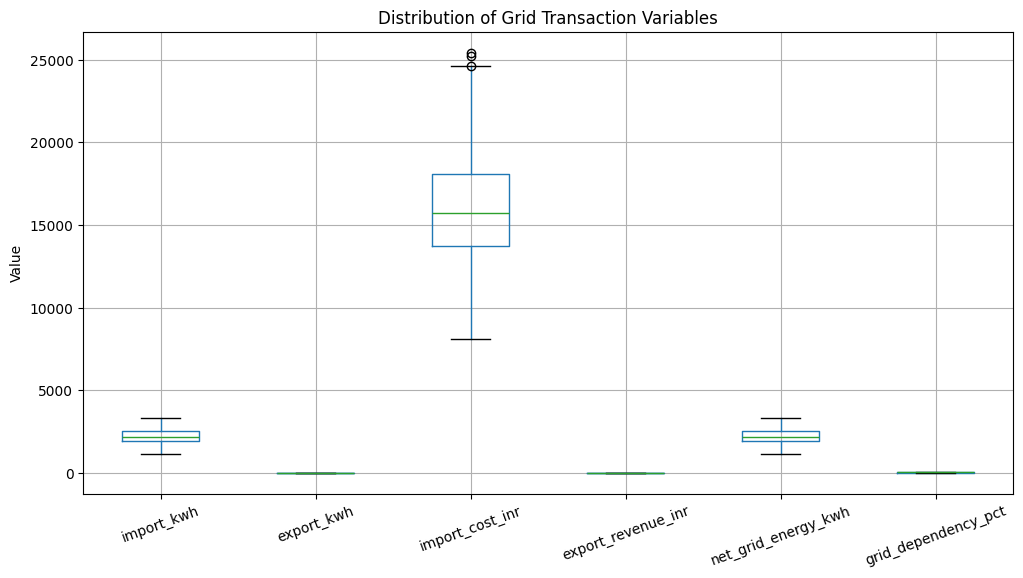

In [ ]:
import matplotlib.pyplot as plt

grid_df[
    [
        'import_kwh',
        'export_kwh',
        'import_cost_inr',
        'export_revenue_inr',
        'net_grid_energy_kwh',
        'grid_dependency_pct'
    ]
].boxplot(figsize=(12,6))

plt.title('Distribution of Grid Transaction Variables')
plt.ylabel('Value')
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

**❓ Business Question 2**

**Is there a relationship between grid import, net grid energy, grid dependency, and import cost?**

**📘 Correlation Analysis**

In [ ]:
correlation = grid_df[
    [
        'import_kwh',
        'net_grid_energy_kwh',
        'grid_dependency_pct',
        'import_cost_inr'
    ]
].corr()

print(correlation.round(3))

                     import_kwh  net_grid_energy_kwh  grid_dependency_pct  \
import_kwh                1.000                1.000                0.712   
net_grid_energy_kwh       1.000                1.000                0.712   
grid_dependency_pct       0.712                0.712                1.000   
import_cost_inr           0.975                0.975                0.676   

                     import_cost_inr  
import_kwh                     0.975  
net_grid_energy_kwh            0.975  
grid_dependency_pct            0.676  
import_cost_inr                1.000  


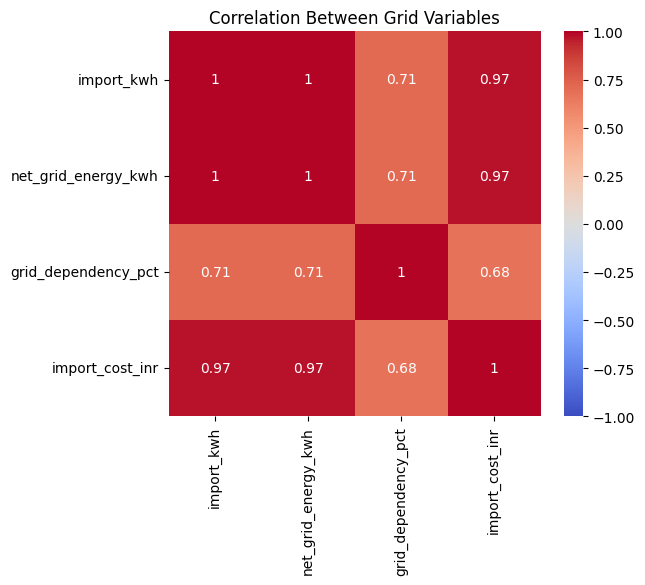

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Grid Variables')

plt.show()

**❓ Business Question 3**

**Does grid cost differ between weekdays and weekends?**

**📘 Independent t-test**

**Hypotheses**

**H₀:** Mean grid import cost is the same on weekdays and weekends.

**H₁:** Mean grid import cost differs between weekdays and weekends.

In [ ]:
grid_weekend_df = grid_df.merge(
    energy_consumption_df[['campus_id', 'date', 'is_weekend']].drop_duplicates(),
    on=['campus_id', 'date'],
    how='left'
)

In [ ]:
weekday_cost = grid_weekend_df[
    grid_weekend_df['is_weekend'] == 0
]['import_cost_inr']

weekend_cost = grid_weekend_df[
    grid_weekend_df['is_weekend'] == 1
]['import_cost_inr']

In [ ]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    weekday_cost,
    weekend_cost,
    equal_var=False
)

print(f"T-statistic : {t_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

T-statistic : 0.7341
P-value     : 0.4629


**Fail to Reject H₀**

In [ ]:
print(f"Weekday Mean : {weekday_cost.mean():.2f} INR")
print(f"Weekend Mean : {weekend_cost.mean():.2f} INR")

Weekday Mean : 15860.13 INR
Weekend Mean : 15839.43 INR


/tmp/ipykernel_1585/1126805771.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


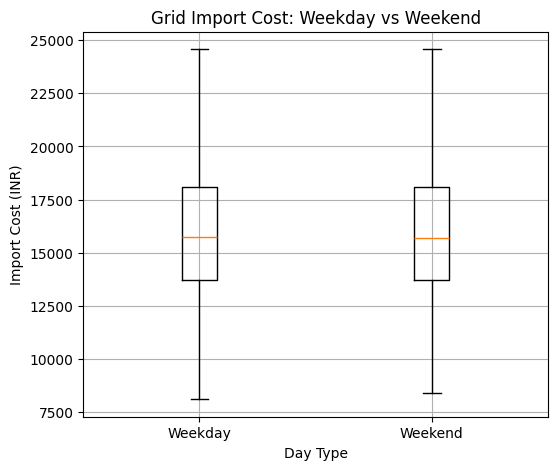

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.boxplot(
    [weekday_cost, weekend_cost],
    labels=['Weekday', 'Weekend'],
    showfliers=False
)

plt.title('Grid Import Cost: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Import Cost (INR)')
plt.grid(True)

plt.show()

**❓ Business Question 5**

**How has grid cost changed over time?**

**📘 Time Series Analysis**

In [ ]:
monthly_cost = (
    grid_df.groupby(
        grid_df['date'].dt.month
    )['import_cost_inr']
    .sum()
    .reset_index()
)

monthly_cost.columns = ['month', 'import_cost_inr']

print(monthly_cost.round(2))

    month  import_cost_inr
0       1      81408662.67
1       2      75329521.99
2       3      86674693.45
3       4      74467847.20
4       5      64225437.44
5       6      55612557.23
6       7      58568667.52
7       8      66615758.25
8       9      74793640.44
9      10      76052924.17
10     11      74914730.28
11     12      79354707.71


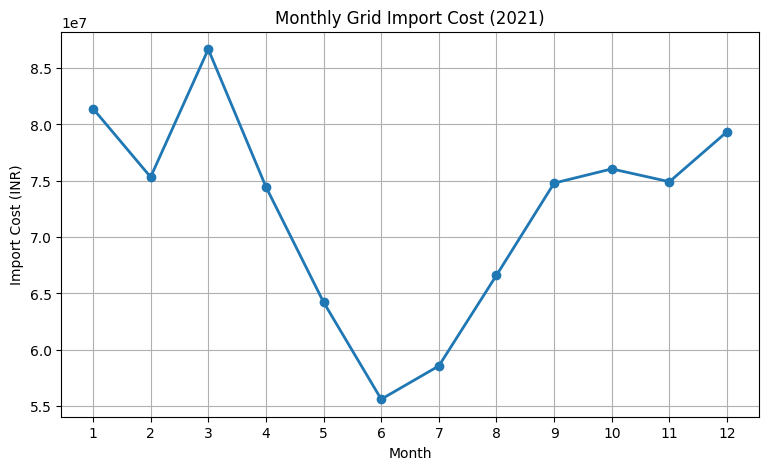

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(
    monthly_cost['month'],
    monthly_cost['import_cost_inr'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Grid Import Cost (2021)')
plt.xlabel('Month')
plt.ylabel('Import Cost (INR)')
plt.xticks(range(1,13))
plt.grid(True)

plt.show()


# **Maintainance Dataset**


---



In [ ]:
maintainance_df = pd.read_excel("/content/Fact_Maintenance_2021_Cleaned.xlsx")

In [ ]:
maintainance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7196 entries, 0 to 7195
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   maintenance_id         7196 non-null   int64         
 1   asset_id               7196 non-null   int64         
 2   maintenance_date       7196 non-null   datetime64[ns]
 3   maintenance_type       7196 non-null   object        
 4   maintenance_cost_inr   7196 non-null   float64       
 5   downtime_hours         7196 non-null   float64       
 6   efficiency_before_pct  7196 non-null   float64       
 7   efficiency_after_pct   7196 non-null   float64       
 8   technician_hours       7196 non-null   float64       
 9   failure_severity       7196 non-null   object        
 10  next_due_date          7196 non-null   datetime64[ns]
 11  maintenance_status     7196 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(2), object(3)
memory u

**❓ Business Question 1**

**What are the typical maintenance cost and downtime patterns in 2021?**

**📘 Descriptive Statistics**

In [ ]:
maintenance_summary = maintainance_df[
    [
        'maintenance_cost_inr',
        'downtime_hours',
        'efficiency_before_pct',
        'efficiency_after_pct',
        'technician_hours'
    ]
].describe().T

print(maintenance_summary.round(2))

                        count      mean       std      min       25%  \
maintenance_cost_inr   7196.0  39524.05  37781.62  8012.09  16451.18   
downtime_hours         7196.0     11.29     12.38     2.00      4.32   
efficiency_before_pct  7196.0     84.60      9.69    45.06     81.22   
efficiency_after_pct   7196.0     90.63      7.17    55.52     88.54   
technician_hours       7196.0      8.24      5.06     3.00      4.95   

                            50%       75%        max  
maintenance_cost_inr   24090.56  51319.32  246258.73  
downtime_hours             6.63     14.06      71.99  
efficiency_before_pct     87.46     91.12      95.00  
efficiency_after_pct      92.25     95.48      99.50  
technician_hours           6.69      9.78      29.92  


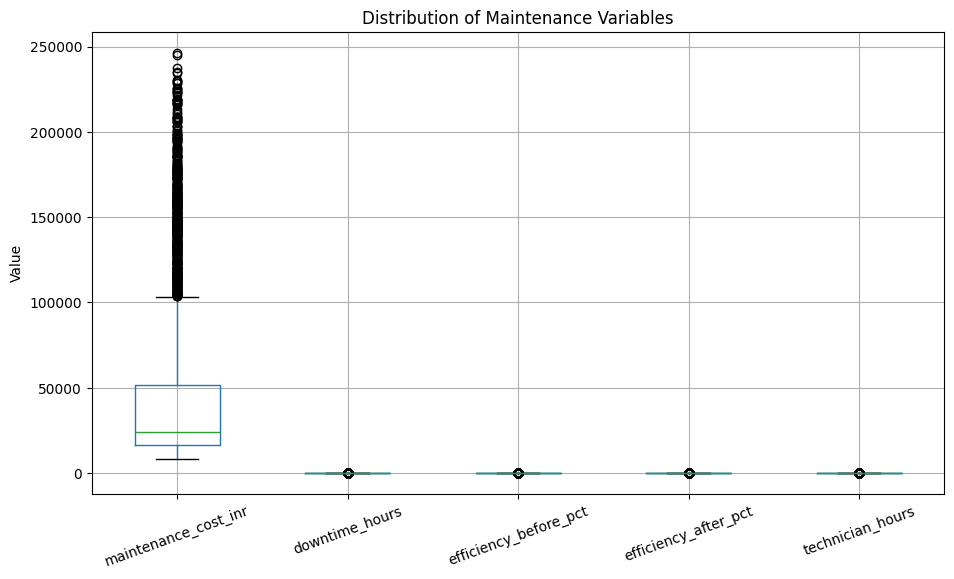

In [ ]:
import matplotlib.pyplot as plt

maintainance_df[
    [
        'maintenance_cost_inr',
        'downtime_hours',
        'efficiency_before_pct',
        'efficiency_after_pct',
        'technician_hours'
    ]
].boxplot(figsize=(11,6))

plt.title('Distribution of Maintenance Variables')
plt.ylabel('Value')
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

maintenance_type
PREVENTIVE    4648
CORRECTIVE    1988
EMERGENCY      560
Name: count, dtype: int64


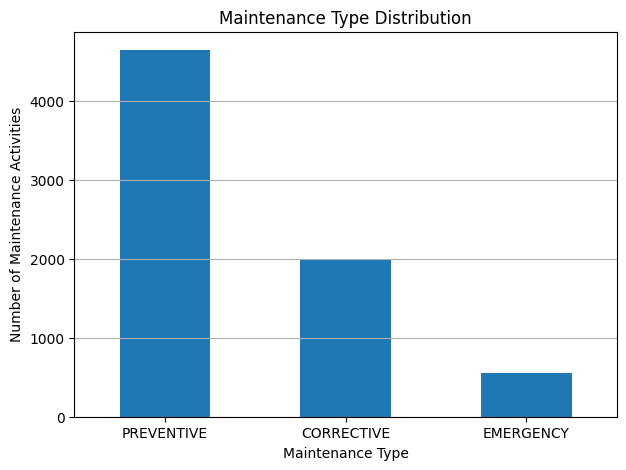

In [ ]:
type_count = maintainance_df['maintenance_type'].value_counts()

print(type_count)

plt.figure(figsize=(7,5))

type_count.plot(kind='bar')

plt.title('Maintenance Type Distribution')
plt.xlabel('Maintenance Type')
plt.ylabel('Number of Maintenance Activities')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

**❓ Business Question 2**

**Is there a relationship between maintenance cost, downtime, and maintenance frequency?**

**📘 Correlation Analysis**

In [ ]:
correlation = maintainance_df[
    [
        'maintenance_cost_inr',
        'downtime_hours',
        'technician_hours',
        'efficiency_before_pct',
        'efficiency_after_pct'
    ]
].corr()

print(correlation.round(3))

                       maintenance_cost_inr  downtime_hours  technician_hours  \
maintenance_cost_inr                  1.000           0.847             0.816   
downtime_hours                        0.847           1.000             0.801   
technician_hours                      0.816           0.801             1.000   
efficiency_before_pct                -0.822          -0.815            -0.790   
efficiency_after_pct                 -0.704          -0.701            -0.676   

                       efficiency_before_pct  efficiency_after_pct  
maintenance_cost_inr                  -0.822                -0.704  
downtime_hours                        -0.815                -0.701  
technician_hours                      -0.790                -0.676  
efficiency_before_pct                  1.000                 0.954  
efficiency_after_pct                   0.954                 1.000  


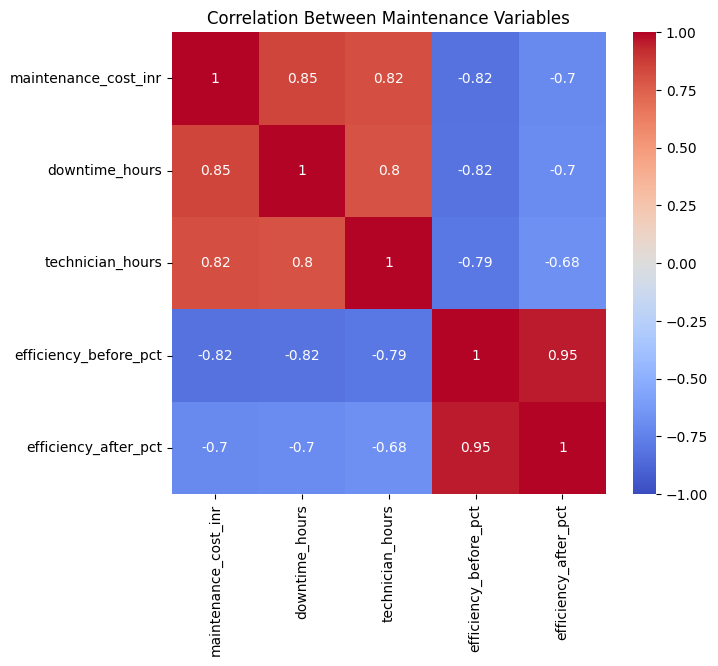

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Maintenance Variables')

plt.show()

**❓ Business Question 3**

**Does maintenance cost differ across maintenance types?**

**📘 ANOVA Analysis**

**Hypotheses**

**H₀:** Mean maintenance cost is the same across all maintenance types.

**H₁:** At least one maintenance type has a different mean maintenance cost.

In [ ]:
type_mean = maintainance_df.groupby(
    'maintenance_type'
)['maintenance_cost_inr'].mean()

print(type_mean.round(2))

maintenance_type
CORRECTIVE     58925.59
EMERGENCY     142712.62
PREVENTIVE     18793.45
Name: maintenance_cost_inr, dtype: float64


In [ ]:
from scipy.stats import f_oneway

preventive = maintainance_df[
    maintainance_df['maintenance_type'] == 'Preventive'
]['maintenance_cost_inr']

corrective = maintainance_df[
    maintainance_df['maintenance_type'] == 'Corrective'
]['maintenance_cost_inr']

emergency = maintainance_df[
    maintainance_df['maintenance_type'] == 'Emergency'
]['maintenance_cost_inr']

f_statistic, p_value = f_oneway(
    preventive,
    corrective,
    emergency
)

print(f"F-statistic : {f_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

F-statistic : nan
P-value     : nan


/tmp/ipykernel_1585/350285441.py:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_statistic, p_value = f_oneway(


**p-value < 0.05**

**Reject H₀**

In [ ]:
summary = maintainance_df.groupby(
    'maintenance_type'
)['maintenance_cost_inr'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
)

print(summary.round(2))

                  Count       Mean     Median       Std       Min        Max
maintenance_type                                                            
CORRECTIVE         1988   58925.59   58211.53  17648.91  25778.06  102949.34
EMERGENCY           560  142712.62  140762.06  37497.81  70697.58  246258.73
PREVENTIVE         4648   18793.45   18590.43   5811.39   8012.09   31944.77


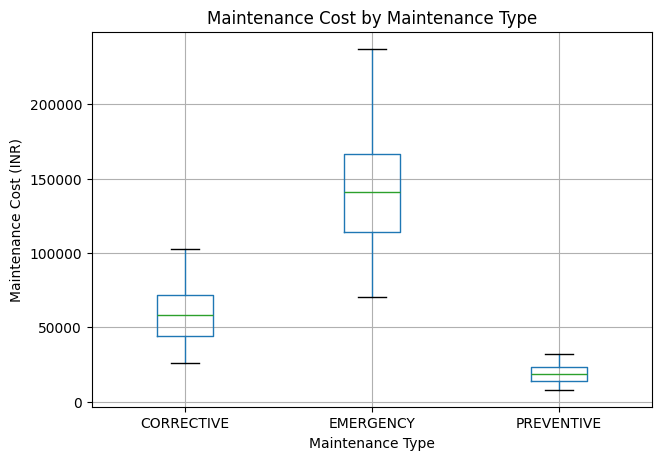

In [ ]:
import matplotlib.pyplot as plt

maintainance_df.boxplot(
    column='maintenance_cost_inr',
    by='maintenance_type',
    figsize=(7,5),
    showfliers=False
)

plt.title('Maintenance Cost by Maintenance Type')
plt.suptitle('')
plt.xlabel('Maintenance Type')
plt.ylabel('Maintenance Cost (INR)')
plt.grid(True)

plt.show()

**❓ Business Question 4**

**How have maintenance costs changed over time?**

**📘 Time Series Analysis**

In [ ]:
maintainance_df['maintenance_date'] = pd.to_datetime(
    maintainance_df['maintenance_date']
)

In [ ]:
monthly_cost = (
    maintainance_df.groupby(
        maintainance_df['maintenance_date'].dt.month
    )['maintenance_cost_inr']
    .sum()
    .reset_index()
)

monthly_cost.columns = ['month', 'maintenance_cost_inr']

print(monthly_cost.round(2))

    month  maintenance_cost_inr
0       1           22832755.80
1       2           22184793.96
2       3           24340641.87
3       4           22073221.42
4       5           23304122.56
5       6           24019324.33
6       7           25511788.35
7       8           23890791.77
8       9           24785831.56
9      10           24259565.19
10     11           22888067.24
11     12           24324195.55


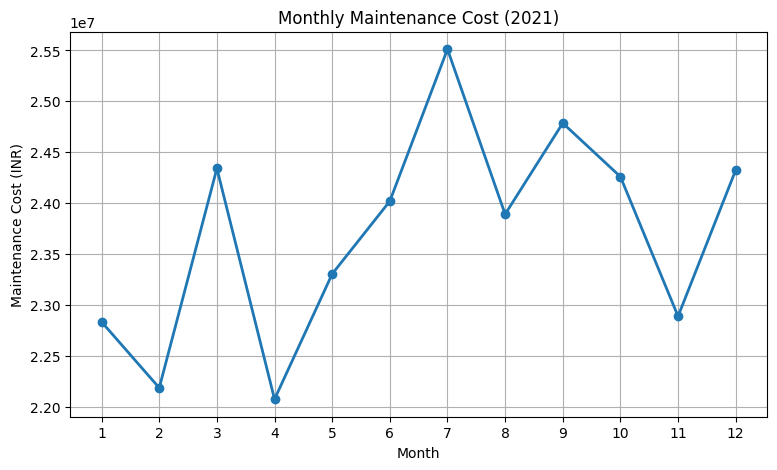

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(
    monthly_cost['month'],
    monthly_cost['maintenance_cost_inr'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Maintenance Cost (2021)')
plt.xlabel('Month')
plt.ylabel('Maintenance Cost (INR)')
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

**Monthly maintenance costs fluctuated throughout 2021, indicating variations in maintenance activities across different months.**



---

